In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [32]:
data = load_breast_cancer()

X = data.data
y = data.target

print(X.shape)  # (569, 30)

(569, 30)


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [34]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [35]:
model = Sequential([
  Dense(16, activation='relu', input_shape=(30,)),
  Dense(8, activation='relu'),
  Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [37]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.7802 - loss: 0.5257 - val_accuracy: 0.8462 - val_loss: 0.4196
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9148 - loss: 0.3364 - val_accuracy: 0.8681 - val_loss: 0.3248
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9341 - loss: 0.2568 - val_accuracy: 0.8901 - val_loss: 0.2749
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9478 - loss: 0.2083 - val_accuracy: 0.9011 - val_loss: 0.2383
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9533 - loss: 0.1732 - val_accuracy: 0.8901 - val_loss: 0.2127
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9588 - loss: 0.1492 - val_accuracy: 0.9011 - val_loss: 0.1922
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9643 - loss: 0.1304 - val_accuracy: 0.9121 - val_loss: 0.1778
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9615 - loss: 0.1168 - val_accuracy: 0.9231 - val_loss

In [38]:
loss, accuracy = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9737 - loss: 0.0793

Test Accuracy: 0.9736841917037964


In [39]:
loss, accuracy = model.evaluate(X_train, y_train)
print("\nTest Accuracy:", accuracy)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9890 - loss: 0.0311

Test Accuracy: 0.9890109896659851


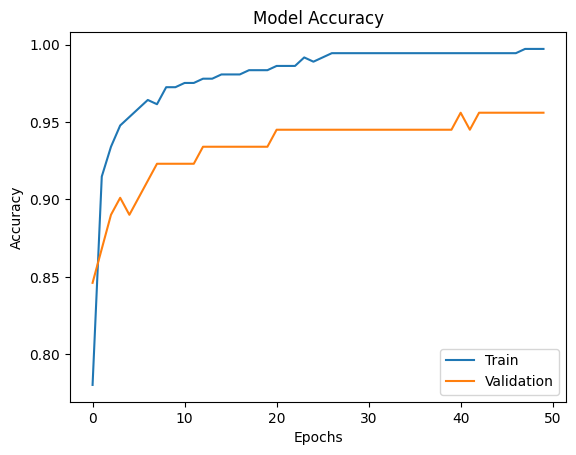

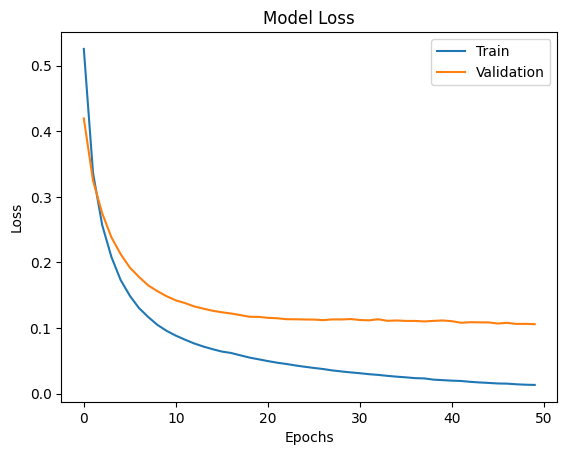

In [40]:
# Accuracy plot
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(['Train', 'Validation'])
plt.show()

# Loss plot
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['Train', 'Validation'])
plt.show()

In [41]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step

Confusion Matrix:
 [[41  2]
 [ 1 70]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

